In [1]:
import pandas as pd
import ultraplot as uplt
import numpy as np

In [2]:
df = pd.read_csv('../data/parameter_sweep_dist_morph_split_test2.csv')
params = pd.read_csv('../data/parameter_sweep_parameter_list_exp2.csv')

In [12]:
param_index = np.ones(len(df))
lookup_index = df.lookup_index
for idx in range(1, len(lookup_index)):
    if lookup_index[idx] < lookup_index[idx - 1]:
        param_index[idx:] += 1
        
df["param_index"] = param_index.astype(int)   
df = params.merge(df, left_on="index", right_on="param_index", how="inner")

Checking the sensitivity of parameters at the level of individual floes

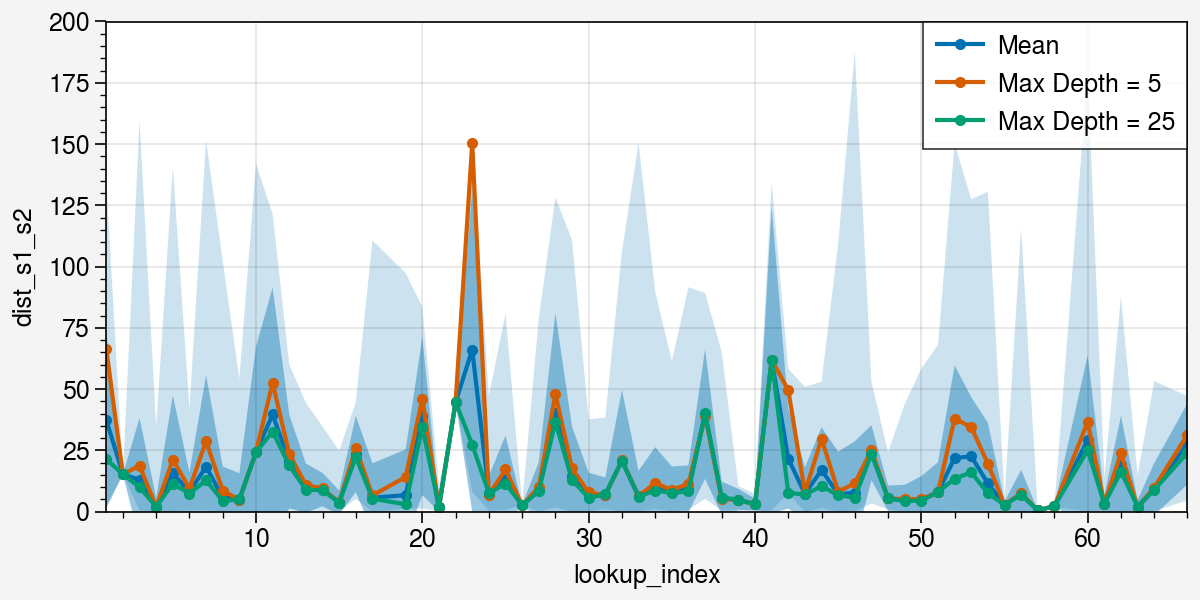

In [45]:
fig, ax = uplt.subplots(width=6, height=3)

ax.plot(df.groupby("lookup_index").mean()["dist_s1_s2"],
        shadedata=
        df.groupby("lookup_index").std()["dist_s1_s2"],
        fadedata=[
        df.groupby("lookup_index").min()["dist_s1_s2"],
        df.groupby("lookup_index").max()["dist_s1_s2"]],
    marker=".", label="Mean")
ax.plot(df.loc[df.max_depth == 5, :].groupby("lookup_index").mean()["dist_s1_s2"], marker=".", label="Max Depth = 5")
ax.plot(df.loc[df.max_depth == 25, :].groupby("lookup_index").mean()["dist_s1_s2"], marker=".", label="Max Depth = 25")
ax.legend(loc='ur', ncols=1)
ax.format(ylim=(0, 200))

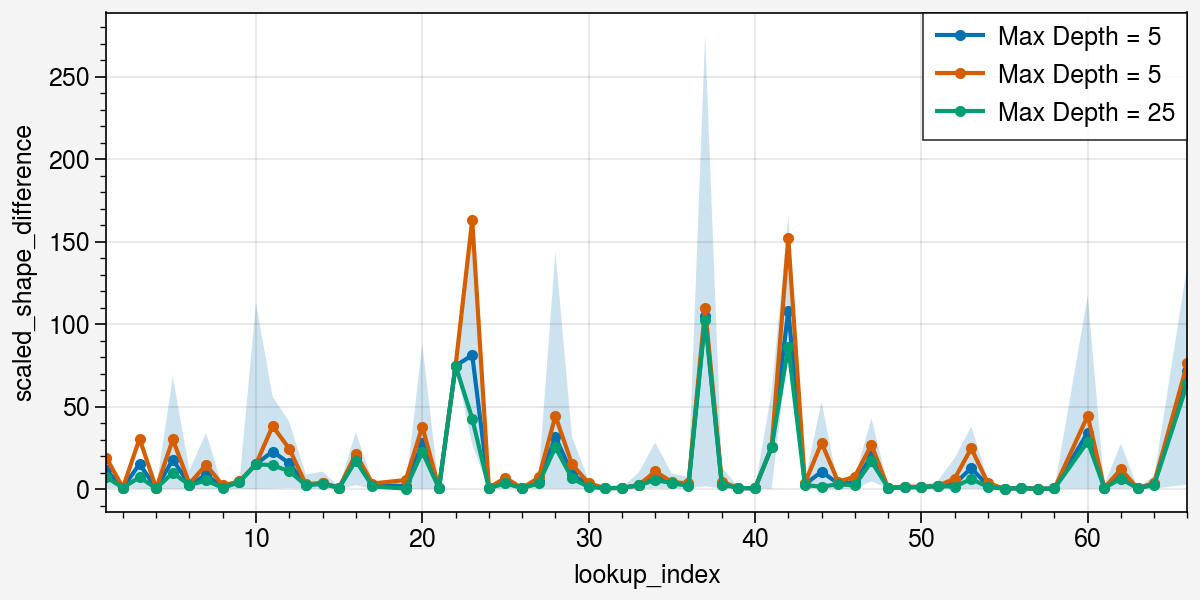

In [39]:
fig, ax = uplt.subplots(width=6, height=3)

ax.plot(df.groupby("lookup_index").mean()["scaled_shape_difference"],
        fadedata=[
        df.groupby("lookup_index").quantile(0.9)["scaled_shape_difference"],
        df.groupby("lookup_index").quantile(0.1)["scaled_shape_difference"]],
    marker=".", label="Max Depth = 5")
ax.plot(df.loc[df.max_depth == 5, :].groupby("lookup_index").mean()["scaled_shape_difference"], marker=".", label="Max Depth = 5")
ax.plot(df.loc[df.max_depth == 25, :].groupby("lookup_index").mean()["scaled_shape_difference"], marker=".", label="Max Depth = 25")
ax.legend(loc='ur', ncols=1)

In [52]:
df.max_depth.unique()

array([ 5, 15, 25])

In [53]:
df.max_depth_ratio.unique()

array([0.5  , 0.625, 0.75 ])

In [54]:
df.opening_strel_radius.unique()

array([1, 2, 3, 4, 5])

In [58]:
idx = df.opening_strel_radius == 1

In [59]:
idx

0         True
1         True
2         True
3         True
4         True
         ...  
57195    False
57196    False
57197    False
57198    False
57199    False
Name: opening_strel_radius, Length: 57200, dtype: bool

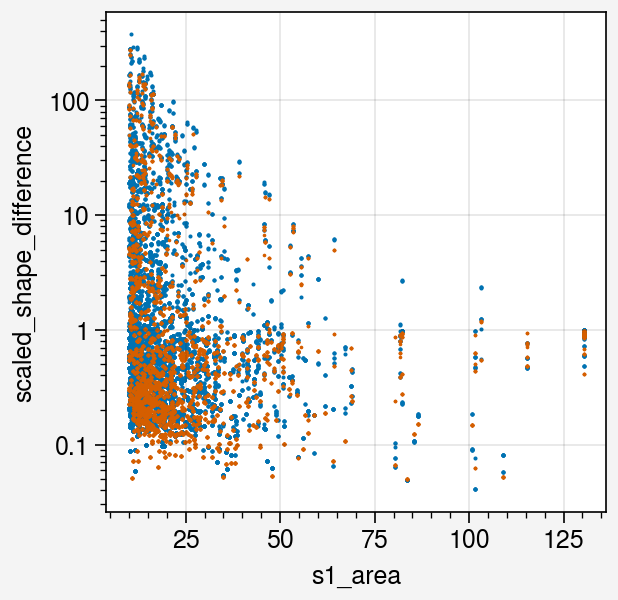

In [65]:
fig, ax = uplt.subplots()
idx = df.opening_strel_radius == 1
ax.scatter(df.loc[idx, "s1_area"]**0.5, df.loc[idx, "scaled_shape_difference"], m='.', ms=3)
idx = df.opening_strel_radius == 5
ax.scatter(df.loc[idx, "s1_area"]**0.5, df.loc[idx, "scaled_shape_difference"], m='.', ms=2)
ax.format(yscale='log')

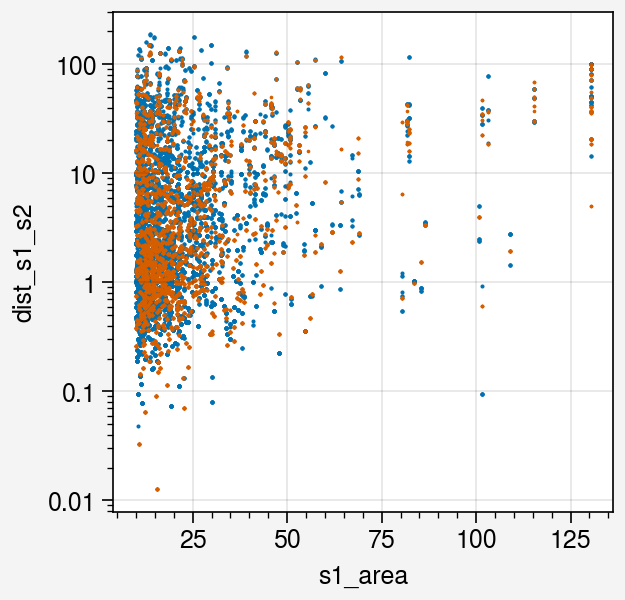

In [66]:
fig, ax = uplt.subplots()
idx = df.opening_strel_radius == 1
ax.scatter(df.loc[idx, "s1_area"]**0.5, df.loc[idx, "dist_s1_s2"], m='.', ms=3)
idx = df.opening_strel_radius == 5
ax.scatter(df.loc[idx, "s1_area"]**0.5, df.loc[idx, "dist_s1_s2"], m='.', ms=2)
ax.format(yscale='log')

In [31]:
ax.plot(df.groupby("lookup_index").mean()["dist_s1_s2"], marker=".", label="Mean")
ax.plot(
    df.loc[df.max_depth == 5, :].groupby("lookup_index").mean()["dist_s1_s2"],
    shadedata=[
        df.loc[df.max_depth == 5, :].groupby("lookup_index").max()["dist_s1_s2"],
        df.loc[df.max_depth == 5, :].groupby("lookup_index").min()["dist_s1_s2"]],
    marker=".", label="Max Depth = 5")
ax.plot(df.loc[df.max_depth == 25, :].groupby("lookup_index").mean()["dist_s1_s2"], marker=".", label="Max Depth = 25")
ax.legend(loc='ur', ncols=1)